# Micro-organism Image Classification — ResNet50 (Pretrained, Fine-Tuned)

**Why this notebook?** This project already has a frozen `MobileNetV2` notebook and a fine-tuned
`EfficientNetB0` notebook. This one swaps in a third, historically pivotal pretrained backbone:
**ResNet50** — and, since ResNet's core idea (the **residual connection**) is exactly the concept
this project's AlexNet/VGG/GoogLeNet notebook flagged as "what comes next," this notebook also
includes a full theory section on how it actually works, the same way the from-scratch notebooks do.

**What's the same as the EfficientNetB0 notebook:**
- Two-phase training — **Phase 1** freezes the pretrained base and trains only a new head, then
  **Phase 2** unfreezes part of the base and fine-tunes everything together with a tiny learning rate.
- **Class weights**, so rarer micro-organism types aren't drowned out by more common ones.
- Same dataset, same steps, same beginner-friendly comments throughout.

**What's different:** ResNet50 is a **deeper, older (2015) architecture built around residual
("skip") connections**, rather than the compound-scaled, mobile-oriented design of EfficientNetB0.
Step 7 below explains exactly what that means and why it mattered enough to win ILSVRC 2015.

## Step 1: Import the Libraries

Same as the EfficientNetB0 notebook, with `ResNet50` and its matching `preprocess_input` swapped in.

- `os` and `pathlib` — for working with folders and file paths.
- `numpy` — for numerical operations.
- `matplotlib.pyplot` — for plotting images and graphs.
- `tensorflow` / `keras` — the deep learning library, including `ResNet50` and
  `tensorflow.keras.applications.resnet50.preprocess_input` (more on why this one is a little
  different from EfficientNet's version in Step 5).
- `sklearn.utils.class_weight` — to compute class weights that account for any imbalance between
  how many images each micro-organism type has.

In [1]:
# Basic Python tools for handling files and folders
import os
from pathlib import Path

# Numerical operations
import numpy as np

# For plotting images and graphs
import matplotlib.pyplot as plt

# Deep learning library
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Used to compute class weights for imbalanced datasets
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Step 2: Set the Dataset Path and Basic Parameters

- `IMG_HEIGHT`, `IMG_WIDTH` — 224x224, the standard input size `ResNet50` expects (and the same size
  used everywhere else in this project).
- `PHASE1_EPOCHS` — how long we train with the base model frozen.
- `PHASE2_EPOCHS` — how long we continue training during fine-tuning.
- `FINE_TUNE_LAYERS` — how many of the base model's final layers to unfreeze during fine-tuning. We
  keep this at 30, same as the EfficientNetB0 notebook — and, conveniently, Step 7 shows this happens
  to line up almost exactly with unfreezing ResNet50's entire last residual stage (`conv5_x`).

**Important:** Update `DATASET_DIR` below if your folder path is different.

In [2]:
# Path to the main dataset folder (one sub-folder per micro-organism type).
from google.colab import drive
drive.mount('/content/drive')

# Then update your dataset path to point to Drive
DATASET_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Micro_Organism")

# ResNet50's standard input size
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 32

# Phase 1: train only the new head, with the base model frozen
PHASE1_EPOCHS = 10

# Phase 2: fine-tune the unfrozen part of the base model together with the head
PHASE2_EPOCHS = 15

# How many of ResNet50's final layers to unfreeze during fine-tuning.
# We keep the earlier layers frozen because they hold very general, broadly useful features
# (edges, colors, simple textures) that don't need to change for a new dataset.
FINE_TUNE_LAYERS = 30

VALIDATION_SPLIT = 0.2
SEED = 42

Mounted at /content/drive


## Step 3: Explore the Dataset

Check the micro-organism type names and how many images each one has. We'll reuse `image_counts`
further down to compute class weights.

In [3]:
class_names = sorted([folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir()])

print("Number of micro-organism types (classes) found:", len(class_names))
for name in class_names:
    print(" -", name)

Number of micro-organism types (classes) found: 8
 - Amoeba
 - Euglena
 - Hydra
 - Paramecium
 - Rod_bacteria
 - Spherical_bacteria
 - Spiral_bacteria
 - Yeast


Number of images per micro-organism type:
 - Amoeba: 72 images
 - Euglena: 168 images
 - Hydra: 76 images
 - Paramecium: 152 images
 - Rod_bacteria: 85 images
 - Spherical_bacteria: 86 images
 - Spiral_bacteria: 75 images
 - Yeast: 75 images

Total images: 789


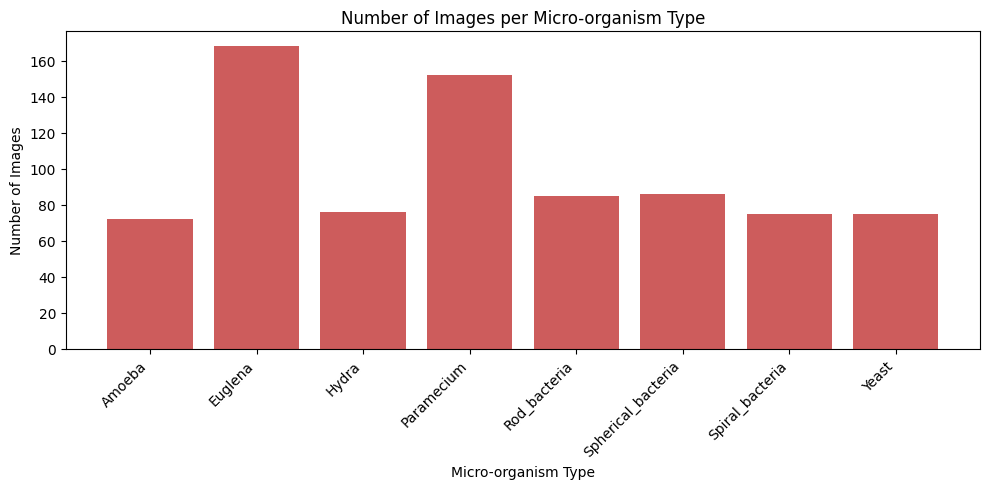

In [4]:
image_counts = {}

for class_name in class_names:
    class_folder = DATASET_DIR / class_name
    num_images = len([f for f in class_folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    image_counts[class_name] = num_images

print("Number of images per micro-organism type:")
for class_name, count in image_counts.items():
    print(f" - {class_name}: {count} images")

print("\nTotal images:", sum(image_counts.values()))

plt.figure(figsize=(10, 5))
plt.bar(image_counts.keys(), image_counts.values(), color="indianred")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Micro-organism Type")
plt.ylabel("Number of Images")
plt.title("Number of Images per Micro-organism Type")
plt.tight_layout()
plt.show()

## Step 4: Visualize Sample Images

A quick visual check that the images loaded correctly, and a reminder of what each micro-organism
type actually looks like under the microscope before we start building the model.

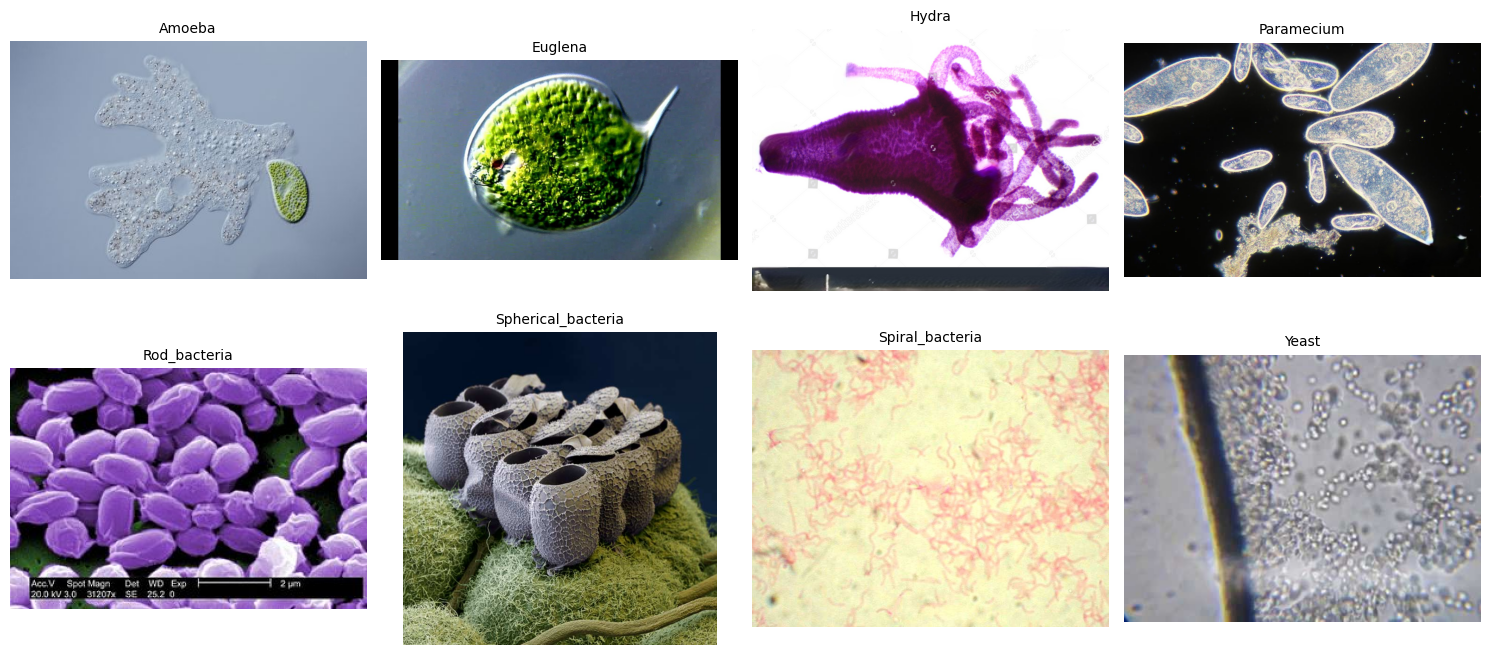

In [5]:
plt.figure(figsize=(15, 10))

for i, class_name in enumerate(class_names):
    class_folder = DATASET_DIR / class_name

    image_files = [f for f in class_folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    if len(image_files) == 0:
        continue
    sample_image_path = image_files[0]

    img = keras.preprocessing.image.load_img(sample_image_path)
    plt.subplot(3, 4, i + 1)  # Adjust grid size (rows, cols) if you have more/fewer classes
    plt.imshow(img)
    plt.title(class_name, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 5: Prepare the Data for Training

Like the EfficientNetB0 notebook, we use each pretrained model's own matching `preprocess_input`
instead of a plain `rescale=1./255` — every pretrained model expects its input prepared in the exact
way it was originally trained on.

**One real difference worth knowing:** `EfficientNetB0`'s `preprocess_input` scales pixel values,
but `ResNet50`'s is older and does something a bit different — it was written to match the original
Caffe implementation the ResNet authors used. It:
1. Converts the image from **RGB to BGR** (swaps the red and blue channels), and
2. **Subtracts a fixed ImageNet mean value** from each channel (no scaling to `[-1, 1]` or `[0, 1]`
   at all).

This doesn't change how we train — `flow_from_directory` and `preprocess_input` handle it
automatically either way — but it *does* mean that later, in Step 13, displaying a sample image
needs an extra step to undo the channel swap, not just a simple rescale.

Augmentation settings are the same as before — random rotation, shifting, zoom, and flipping on the
training data only.

In [6]:
# preprocess_input handles converting to BGR and mean-subtraction, exactly the way ResNet50 expects.
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=VALIDATION_SPLIT
)

# Validation data: same preprocessing, no augmentation
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=VALIDATION_SPLIT
)

In [7]:
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED
)

validation_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED
)

print("Class indices used by the model:", train_generator.class_indices)

Found 633 images belonging to 8 classes.
Found 156 images belonging to 8 classes.
Class indices used by the model: {'Amoeba': 0, 'Euglena': 1, 'Hydra': 2, 'Paramecium': 3, 'Rod_bacteria': 4, 'Spherical_bacteria': 5, 'Spiral_bacteria': 6, 'Yeast': 7}


## Step 6: Compute Class Weights

Looking back at the bar chart in Step 3, some micro-organism types likely have more images than
others. Without correcting for this, the model can get a misleadingly high accuracy just by favoring
whichever type has the most examples, while doing poorly on the rarer ones.

`compute_class_weight` gives each class a weight: types with fewer images get a *higher* weight, so
mistakes on those types count for more during training, encouraging the model to pay attention to
them too.

In [8]:
# train_generator.classes holds the numeric class label for every single training image
class_labels = np.unique(train_generator.classes)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=train_generator.classes
)

# Keras expects class weights as a dictionary: {class_index: weight}
class_weights = dict(zip(class_labels, class_weights_array))

print("Class weights (higher = fewer training images for that type):")
for class_index, weight in class_weights.items():
    type_name = [name for name, idx in train_generator.class_indices.items() if idx == class_index][0]
    print(f" - {type_name}: {weight:.2f}")

Class weights (higher = fewer training images for that type):
 - Amoeba: 1.36
 - Euglena: 0.59
 - Hydra: 1.30
 - Paramecium: 0.65
 - Rod_bacteria: 1.16
 - Spherical_bacteria: 1.15
 - Spiral_bacteria: 1.32
 - Yeast: 1.32


## Step 7: Theory — Inside ResNet50's Architecture

This is the idea the AlexNet/VGG/GoogLeNet notebook's closing section already pointed toward:
plain, very deep networks eventually get *harder* to train, not just riskier to overfit — and
**ResNet** (He, Zhang, Ren & Sun, Microsoft Research, 2015) is the architecture that fixed it,
winning ILSVRC 2015 with a **3.57% top-5 error** (down from GoogLeNet's 6.67% the year before).

1. **The degradation problem: deeper isn't automatically better.** VGG already showed that stacking
   more uniform 3x3 layers improves accuracy — up to a point. The ResNet paper's key observation was
   that once plain (non-residual) networks get deep enough, accuracy **saturates and then gets
   *worse* — and, surprisingly, *training* error gets worse too, not just validation error.** That
   rules out overfitting as the cause. The real problem is **optimization**: it becomes genuinely
   harder for a long stack of nonlinear layers to learn to behave well, even if, in principle, doing
   nothing extra (an identity mapping) would have been perfectly fine at that depth.

2. **The fix: residual ("skip") connections.** Instead of asking a block of layers to learn a direct
   mapping `H(x)`, ResNet reframes the problem: let the block learn a **residual** `F(x) = H(x) - x`,
   then add the block's own input back on at the end: `output = F(x) + x`. The `+ x` part is a
   **shortcut connection** that skips over the block entirely. Two big advantages fall out of this:
   - If extra depth genuinely isn't helping at some point, it's far easier for a block to learn
     `F(x) = 0` (doing nothing, so `output = x`) than for a stack of nonlinear layers to somehow learn
     a perfect identity mapping directly.
   - During backpropagation, the shortcut gives gradients a direct, unobstructed path back through
     the network — a "gradient highway" — instead of forcing every single gradient to pass through
     every nonlinear transformation on the way back.

3. **Bottleneck blocks: 1x1 -> 3x3 -> 1x1.** ResNet50 (and the deeper ResNet101/152) use "bottleneck"
   residual blocks: a `1x1` convolution first **reduces** the channel count, a `3x3` convolution does
   the actual spatial processing at that narrower width, and a final `1x1` convolution **expands** the
   channels back up — and *then* the shortcut is added. This channel-reduce-then-expand pattern
   should look familiar: **it's the exact same 1x1 bottleneck trick used inside GoogLeNet's Inception
   modules** (see that notebook's Step 6) — just arranged one-after-another in a single path here,
   instead of as parallel branches.

4. **Why "50"?** ResNet50's layers are organized into a stem, then **4 stages** of bottleneck blocks,
   with **3, 4, 6, and 3 blocks** respectively (16 blocks in total — which is exactly how many `Add`
   layers you'll count in the model summary below, one per block). Each bottleneck block has 3
   convolutions, so `16 x 3 = 48`, plus the stem's first convolution, plus one final fully-connected
   classification layer in the *original* 1000-class design = **50** weight layers total. That
   counting convention (weight layers along the longest path) is the same one behind "GoogLeNet: 22
   layers" in the previous notebook.

5. **Projection shortcuts, for when shapes don't match.** A pure identity shortcut (`output = F(x) +
   x`) only works when `F(x)` and `x` are the exact same shape. At the *start* of each new stage, the
   spatial size shrinks and the channel count changes — so ResNet uses a small `1x1` convolution
   (with a matching stride) on the shortcut path too, just enough to reshape it before adding. Every
   other block within a stage, where the shape doesn't change, uses a plain, parameter-free identity
   shortcut instead.

6. **BatchNormalization after every convolution.** Unlike AlexNet or the original VGG (both of which
   predate BatchNorm), ResNet (2015) was designed with it from the start — one more reason it trains
   more reliably at this depth than a hypothetical plain 50-layer stack would.

**Shape, from a 224x224x3 input — verified by actually building and inspecting this exact model:**

| Stage | Keras layer name | Blocks | Output shape |
|---|---|---|---|
| Input | — | — | 224x224x3 |
| Stem | `conv1` (7x7/2) + `pool1_pool` (3x3/2) | — | 56x56x64 |
| Stage 1 | `conv2_x` | 3 bottleneck blocks | 56x56x256 |
| Stage 2 | `conv3_x` | 4 bottleneck blocks | 28x28x512 |
| Stage 3 | `conv4_x` | 6 bottleneck blocks | 14x14x1024 |
| Stage 4 | `conv5_x` | 3 bottleneck blocks | 7x7x2048 |
| Head (this notebook) | `GlobalAveragePooling2D` + `Dense(128)` + `Dropout` | — | 128 |
| Output | `Dense` + `Softmax` | — | `num_classes` |

**Why use it as a *pretrained* backbone (rather than building it from scratch, like AlexNet/VGG/
GoogLeNet earlier in this project)?** Because residual connections let ResNet50 actually train
successfully to a genuine 50 layers of *effective* depth — not just 50 layers on paper — its
ImageNet-pretrained features are unusually rich for a network of its era. That's exactly why,
despite being a full decade old, ResNet50 is still a common, dependable choice as a pretrained
feature extractor today, which is what we build in Step 8.

## Step 8: Build the Model — ResNet50 Base + Classification Head

Same overall idea as the other transfer-learning notebooks: load a pretrained base model without its
original classification layer, freeze it, and add our own head on top.

`include_top=False` removes ResNet50's original 1000-class ImageNet output layer (and the giant
`Flatten` + `Dense` layers behind it), and `weights="imagenet"` loads its pretrained weights. We
freeze it for Phase 1 so training only affects the new head at first.

In [9]:
base_model = ResNet50(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the entire base model for Phase 1
base_model.trainable = False

print("Number of layers in the base model:", len(base_model.layers))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of layers in the base model: 175


In [10]:
# The same style of classification head as the other transfer-learning notebooks.
# GlobalAveragePooling2D collapses ResNet50's final 7x7x2048 feature maps down to a
# 2048-length vector before handing off to our own, much smaller Dense layers.
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

num_classes = len(class_names)
predictions = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

## Step 9: Phase 1 — Train the Head With the Base Model Frozen

We compile with a normal learning rate here, since only the new (randomly initialized) head is being
trained and it needs to move fairly quickly to start making sensible predictions.

In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,016 (90.98 MB)

 Trainable params: 263,304 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
early_stop_phase1 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint_phase1 = ModelCheckpoint(
    "best_microorganism_resnet50_phase1.keras",
    monitor="val_accuracy",
    save_best_only=True
)

history_phase1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=PHASE1_EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop_phase1, checkpoint_phase1]
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 341s 16s/step - accuracy: 0.3744 - loss: 1.9467 - val_accuracy: 0.5641 - val_loss: 1.3480
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 920ms/step - accuracy: 0.6556 - loss: 1.0276 - val_accuracy: 0.6410 - val_loss: 1.1913
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 899ms/step - accuracy: 0.6983 - loss: 0.8930 - val_accuracy: 0.6603 - val_loss: 1.0810
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 858ms/step - accuracy: 0.7820 - loss: 0.6321 - val_accuracy: 0.6603 - val_loss: 1.0567
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 935ms/step - accuracy: 0.8215 - loss: 0.5869 - val_accuracy: 0.6859 - val_loss: 1.0883
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 849ms/step - accuracy: 0.8626 - loss: 0.4182 - val_accuracy: 0.6859 - val_loss: 1.1335
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 868ms/step - accuracy: 0.8641 - loss: 0.3717 - val_accuracy: 0.6538 - val_loss: 1.1367


## Step 10: Phase 2 — Fine-Tune the Base Model

Now we unfreeze the last `FINE_TUNE_LAYERS` layers of ResNet50 and continue training, letting those
deeper layers adjust slightly to microscope-image-specific patterns. As Step 7 covers, 30 layers here
lines up closely with unfreezing the whole of `conv5_x` — ResNet50's last, most abstract residual
stage — while leaving the more general-purpose early stages untouched.

**Very important:** we use a **much smaller learning rate** here (100x smaller than Phase 1). The
base model's weights are already well-trained from ImageNet — large updates at this stage would
destroy that useful knowledge instead of gently refining it. This is the single most important rule
of fine-tuning: unfreeze, but update very gently.

We also need to re-compile the model after changing which layers are trainable — Keras requires this
whenever `trainable` is changed on existing layers.

In [13]:
# Unfreeze the whole base model...
base_model.trainable = True

# ...then re-freeze everything except the last FINE_TUNE_LAYERS layers
fine_tune_at = len(base_model.layers) - FINE_TUNE_LAYERS
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Unfrozen layers: {len(base_model.layers) - fine_tune_at} out of {len(base_model.layers)}")

Unfrozen layers: 30 out of 175


In [14]:
# Re-compile with a much smaller learning rate now that more of the network can update
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,016 (90.98 MB)

 Trainable params: 14,713,480 (56.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [15]:
early_stop_phase2 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

checkpoint_phase2 = ModelCheckpoint(
    "best_microorganism_resnet50_finetuned.keras",
    monitor="val_accuracy",
    save_best_only=True
)

# Gently reduce the learning rate further if validation loss plateaus during fine-tuning
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

history_phase2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=PHASE2_EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop_phase2, checkpoint_phase2, reduce_lr]
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.7788 - loss: 0.7349 - val_accuracy: 0.6731 - val_loss: 1.0525 - learning_rate: 1.0000e-05
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 941ms/step - accuracy: 0.8294 - loss: 0.5981 - val_accuracy: 0.6667 - val_loss: 1.0483 - learning_rate: 1.0000e-05
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 970ms/step - accuracy: 0.8294 - loss: 0.5384 - val_accuracy: 0.6667 - val_loss: 1.0506 - learning_rate: 1.0000e-05
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 912ms/step - accuracy: 0.8452 - loss: 0.5313 - val_accuracy: 0.6667 - val_loss: 1.0496 - learning_rate: 1.0000e-05
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 902ms/step - accuracy: 0.8594 - loss: 0.4901 - val_accuracy: 0.6538 - val_loss: 1.0502 - learning_rate: 5.0000e-06
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 913ms/step - accuracy: 0.8736 - loss: 0.4558 - val_accuracy: 0.6603 - val_loss: 1.0500 - learning_rate: 5.0000e-06


## Step 11: Plot the Full Training History (Both Phases Combined)

We stitch together the accuracy/loss curves from Phase 1 and Phase 2 into one continuous plot, with a
vertical line marking exactly where fine-tuning began. This makes it easy to see whether fine-tuning
actually helped push accuracy higher than Phase 1 alone achieved.

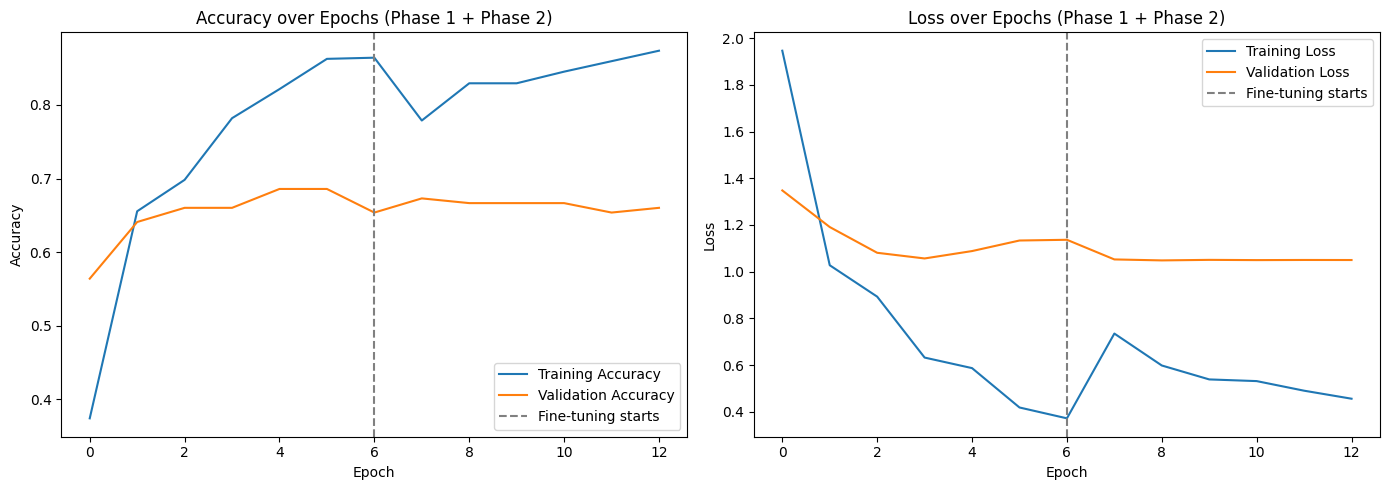

In [16]:
acc = history_phase1.history["accuracy"] + history_phase2.history["accuracy"]
val_acc = history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"]
loss = history_phase1.history["loss"] + history_phase2.history["loss"]
val_loss = history_phase1.history["val_loss"] + history_phase2.history["val_loss"]

phase1_len = len(history_phase1.history["accuracy"])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.axvline(x=phase1_len - 1, color="gray", linestyle="--", label="Fine-tuning starts")
plt.title("Accuracy over Epochs (Phase 1 + Phase 2)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.axvline(x=phase1_len - 1, color="gray", linestyle="--", label="Fine-tuning starts")
plt.title("Loss over Epochs (Phase 1 + Phase 2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Step 12: Evaluate the Model

Check the final validation accuracy and loss. Compare this number to the frozen MobileNetV2 and
fine-tuned EfficientNetB0 notebooks to see how a deeper, residual-connection-based backbone stacks up.

In [17]:
val_loss_final, val_accuracy_final = model.evaluate(validation_generator)

print(f"Validation Loss: {val_loss_final:.4f}")
print(f"Validation Accuracy: {val_accuracy_final:.4f} ({val_accuracy_final * 100:.2f}%)")

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 414ms/step - accuracy: 0.6667 - loss: 1.0483
Validation Loss: 1.0483
Validation Accuracy: 0.6667 (66.67%)


## Step 13: Test the Model on Some Sample Images

Same sanity check as before — predict micro-organism type for a batch of validation images and
compare to the true labels.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


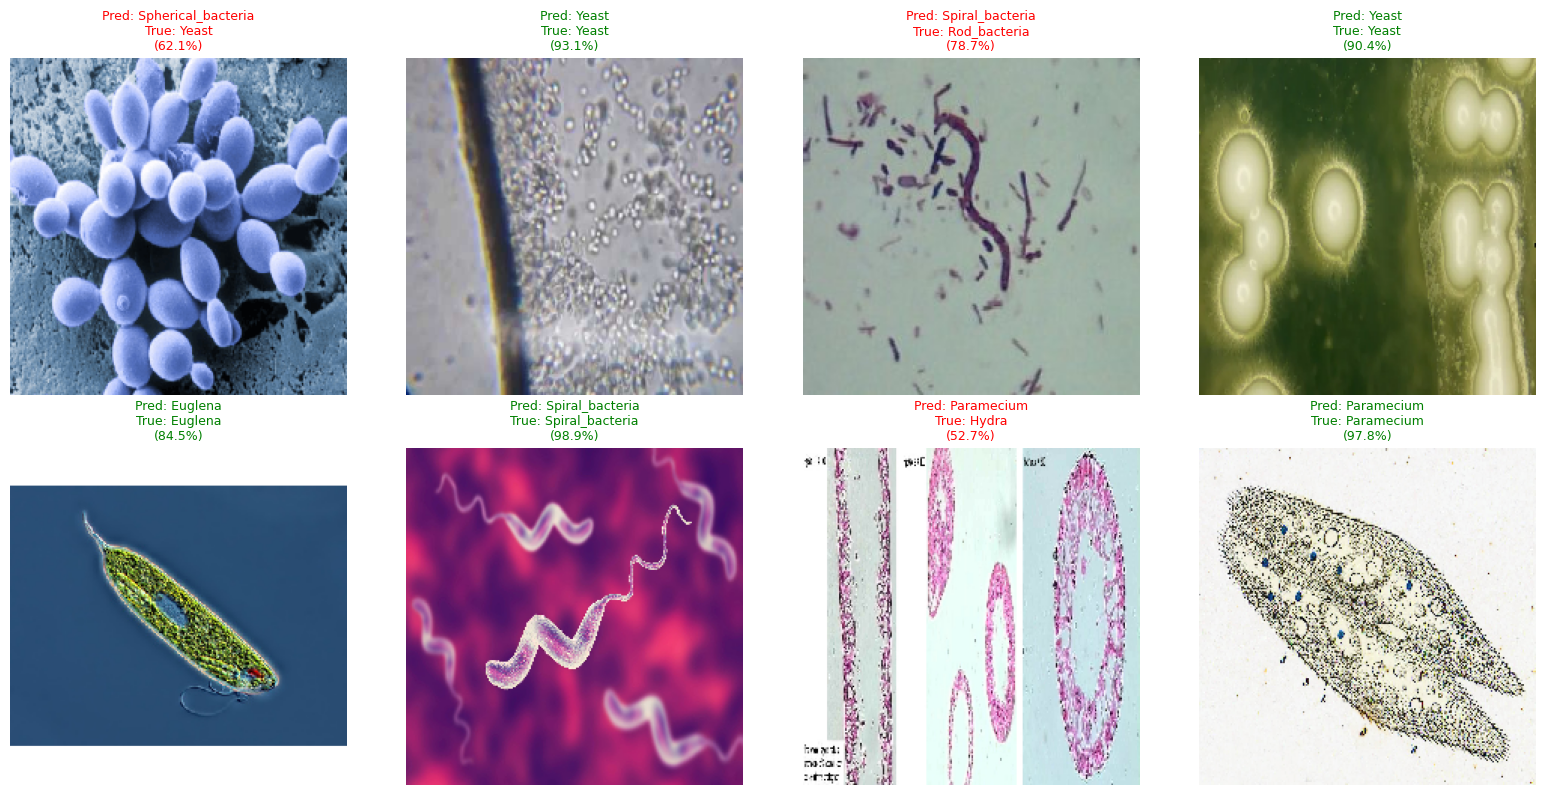

In [18]:
sample_images, sample_labels = next(validation_generator)
predictions = model.predict(sample_images)

index_to_class = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(16, 8))
num_to_show = min(8, len(sample_images))

for i in range(num_to_show):
    plt.subplot(2, 4, i + 1)

    # Undo ResNet50's preprocessing just enough to display the image reasonably.
    # preprocess_input converts RGB -> BGR and subtracts a fixed ImageNet mean per channel
    # (see Step 5), so we reverse both steps: add the means back, then swap the channels
    # back to RGB, before clipping into a displayable [0, 1] range.
    img_display = sample_images[i].copy()
    img_display[..., 0] += 103.939  # B channel
    img_display[..., 1] += 116.779  # G channel
    img_display[..., 2] += 123.68   # R channel
    img_display = img_display[..., ::-1]  # BGR -> RGB
    img_display = np.clip(img_display, 0, 255) / 255.0
    plt.imshow(img_display)

    predicted_class = index_to_class[np.argmax(predictions[i])]
    true_class = index_to_class[np.argmax(sample_labels[i])]
    confidence = np.max(predictions[i]) * 100

    color = "green" if predicted_class == true_class else "red"
    plt.title(f"Pred: {predicted_class}\nTrue: {true_class}\n({confidence:.1f}%)",
              color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 14: Save the Final Model

In [19]:
model.save("microorganism_resnet50_finetuned.keras")
print("Model saved as microorganism_resnet50_finetuned.keras")

Model saved as microorganism_resnet50_finetuned.keras


## Comparing This Notebook to the Other Pretrained Backbones

| | MobileNetV2 (frozen) | EfficientNetB0 (fine-tuned) | ResNet50 (fine-tuned, this notebook) |
|---|---|---|---|
| Year | 2018 | 2019 | 2015 |
| Core idea | Depthwise-separable convolutions, built for mobile devices | Compound scaling (depth + width + resolution together) | Residual ("skip") connections |
| Base model parameters | ~2.3 million | ~4.0 million | ~23.6 million |
| Trainable in this notebook | Only the head | Head + last 30 base layers | Head + last 30 base layers (~all of `conv5_x`) |
| Handles class imbalance | No | Yes, via class weights | Yes, via class weights |

**A quick historical footnote:** ResNet50 is both the *oldest* and, by parameter count, by far the
*largest* of the three pretrained backbones used across this project — a reminder that "newer" and
"more parameter-efficient" aren't the same axis. MobileNetV2 and EfficientNetB0 are both explicitly
designed to squeeze out more accuracy per parameter; ResNet50 instead solved a different problem
entirely (making very deep networks *trainable at all*), and its residual connections are exactly why
this project's from-scratch notebook (AlexNet, VGG16, GoogLeNet) closed by pointing here next.

## Next Steps / Ideas to Improve Further (Optional)

- **Try `ResNet50V2`** — a later revision that reorders BatchNorm/ReLU relative to each convolution
  ("pre-activation"), and often trains slightly better.
- **Unfreeze more layers**: try increasing `FINE_TUNE_LAYERS` (e.g. to also include all of
  `conv4_x`) if you have enough data and training time.
- **Confusion matrix**: build one to see exactly which micro-organism types get confused with each
  other, and compare it against the from-scratch notebooks' mistakes.
- **Compare total parameter counts** across all six notebooks in this project (three from-scratch,
  three pretrained) alongside their validation accuracy, to see the full accuracy-per-parameter
  picture in one place.

In [20]:
from IPython.display import display, Markdown

# Known results from the earlier notebooks in this project -- see those notebooks for details
mobilenet_val_loss, mobilenet_val_accuracy = 1.0590, 0.6667
efficientnet_val_loss, efficientnet_val_accuracy = 1.0385, 0.6667

# ResNet50's own results come straight from Step 12 (Evaluate), computed earlier in this notebook

comparison_text = f"""
## Final Validation Comparison

| Model | Validation Loss | Validation Accuracy |
|---|---:|---:|
| MobileNetV2 (frozen) | {mobilenet_val_loss:.4f} | {mobilenet_val_accuracy * 100:.2f}% |
| EfficientNetB0 (fine-tuned) | {efficientnet_val_loss:.4f} | {efficientnet_val_accuracy * 100:.2f}% |
| ResNet50 (fine-tuned, this notebook) | {val_loss_final:.4f} | {val_accuracy_final * 100:.2f}% |

**Result:** Compare ResNet50's validation loss and accuracy above to the other two pretrained
backbones to see whether its residual-connection-based depth translates into an edge on this
specific dataset.
"""

display(Markdown(comparison_text))


## Final Validation Comparison

| Model | Validation Loss | Validation Accuracy |
|---|---:|---:|
| MobileNetV2 (frozen) | 1.0590 | 66.67% |
| EfficientNetB0 (fine-tuned) | 1.0385 | 66.67% |
| ResNet50 (fine-tuned, this notebook) | 1.0483 | 66.67% |

**Result:** Compare ResNet50's validation loss and accuracy above to the other two pretrained
backbones to see whether its residual-connection-based depth translates into an edge on this
specific dataset.
